# 准备数据

使用孙衍刚的数据训练一下模型

In [29]:
%reset -f
import scanpy as sc

# 4m 5.3s
sc_adata = sc.read("mouseBrain_RNA_counts.h5ad")
sp_adata = sc.read("/media/williamhan/4E44841544840247/Python/bioinformatics_project/MCAO20250929/data/cellbin/MCAO20250929_reduce.h5ad")
sc_adata, sp_adata

(AnnData object with n_obs × n_vars = 378287 × 52198
     obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'libId', 'percent.mt', 'percent.ribo', 'countFeatureRatio', 'sampleId', 'batchId', 'maxPredClass', 'sampleRegion1', 'sampleRegion2', 'sampleRegion3', 'Cell_cluster', 'Cell_group', 'Description', 'Cell_subclass', 'Cell_class', 'Color', 'ident'
     uns: 'X_name'
     obsm: 'HARMONY', 'PCA', 'UMAP'
     layers: 'logcounts',
 AnnData object with n_obs × n_vars = 497563 × 19781
     obs: 'library', 'group', 'sample', 'accession', 'condition', 'time', 'batch', 'dnbCount', 'x', 'y', 'area', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'passing_mt', 'passing_ngenes', '_scvi_batch', '_scvi_labels'
     var: 'mt', 'ribo', 'hb', 'n_cel

In [32]:
sel_col = ["maxPredClass", "Cell_cluster", "Cell_group", "Description", "Cell_subclass", "Cell_class", "Color", "ident"]
sc_adata.obs.loc[:, sel_col].drop_duplicates()

,maxPredClass,Cell_cluster,Cell_group,Description,Cell_subclass,Cell_class,Color,ident
4618-1-211103_CELL1440_N1,Ependymal,EPC_284,EPC,Ependymal cells,Ependymal cells,Ventricular cells,#C87EF6,EPC_284
4618-1-211103_CELL1354_N1,Neurons,CNU_N_GABA_138,CNU_N_GABA,GABAergic neurons in cerebral nuclei,Telencephalon inhibitory neurons,Neurons,#0A5D65,CNU_N_GABA_138
4618-1-211103_CELL926_N2,Neurons,CNU_N_GABA_139,CNU_N_GABA,GABAergic neurons in cerebral nuclei,Telencephalon inhibitory neurons,Neurons,#0F6068,CNU_N_GABA_139
4618-1-211103_CELL8_N2,Neurons,CNU_N_GABA_153,CNU_N_GABA,GABAergic neurons in cerebral nuclei,Telencephalon inhibitory neurons,Neurons,#0FE4F6,CNU_N_GABA_153
4618-1-211103_CELL905_N2,Astrocytes,ASC_277,ASC,Astrocytes,Astrocytes,Astrocytes and olfactory ensheathing cells,#7F9854,ASC_277
...,...,...,...,...,...,...,...,...
R1429_CELL870_N1,Ependymal,CHOR_288,CHOR,Choroid plexus epithelial cells,Choroid plexus epithelial cells,Ventricular cells,#C67AF6,CHOR_288
R1443_CELL1828_N1,Neurons,DIME_N_GLU_204,DIME_N_GLU,Glutamatergic neurons in diencephalon and mese...,Di- and mesencephalon neurons,Neurons,#EEC309,DIME_N_GLU_204
R1443_CELL1904_N1,Neurons,DIME_N_HIS_223,DIME_N_HIS,Histaminergic neurons in diencephalon and mese...,"Cholinergic, monoaminergic, peptidergic neurons",Neurons,#FF2299,DIME_N_HIS_223
4618-2-211103_CELL1224_N2,Neurons,DIME_N_GAL_227,DIME_N_GAL,Galanin-expressing neurons in diencephalon and...,"Cholinergic, monoaminergic, peptidergic neurons",Neurons,#FF1E97,DIME_N_GAL_227


In [37]:
sc_adata.obs.loc[:, ["Cell_group", "Cell_subclass", "Cell_class",]].drop_duplicates().to_csv("Comparison_table.csv")

In [ ]:
for key in ["logcounts"]:
    if key in sc_adata.layers:
        del sc_adata.layers[key]

# uns 和 obsm 是整个容器，不建议直接 del sc_adata.uns / del sc_adata.obsm
# 更稳妥是清空里面的内容
sc_adata.uns.clear()
sc_adata.obsm.clear()

# celltype 必须是 categorical
sc_adata.obs["celltype"] = sc_adata.obs["Cell_group"].astype("category")
# 必须有一列是 celltype
sc_adata.obs = sc_adata.obs.loc[:, ["celltype"]]
sc_adata

AnnData object with n_obs × n_vars = 378287 × 52198
    obs: 'celltype'

In [3]:
import numpy as np

# 1. 确保基因名唯一
sp_adata.var_names_make_unique()
sc_adata.var_names_make_unique()

# 2. 取交集
common_genes = sp_adata.var_names.intersection(sc_adata.var_names)

print(f"sp_adata genes: {sp_adata.n_vars}")
print(f"sc_adata genes: {sc_adata.n_vars}")
print(f"common genes: {len(common_genes)}")

# 3. 按同一组基因、同一顺序切片
sp_adata = sp_adata[:, common_genes].copy()
sc_adata = sc_adata[:, common_genes].copy()

# 4. 确认顺序一致
assert np.array_equal(sp_adata.var_names, sc_adata.var_names)

sc_adata, sp_adata

sp_adata genes: 19781
sc_adata genes: 52198
common genes: 19081


(AnnData object with n_obs × n_vars = 378287 × 19081
     obs: 'celltype',
 AnnData object with n_obs × n_vars = 497563 × 19081
     obs: 'library', 'group', 'sample', 'accession', 'condition', 'time', 'batch', 'dnbCount', 'x', 'y', 'area', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'passing_mt', 'passing_ngenes', '_scvi_batch', '_scvi_labels'
     var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
     uns: 'X_tsne', 'X_umap', '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'log1p', 'neighbors', 'spatial'
     obsm: 'X_s

In [4]:
import numpy as np
import scipy.sparse as sp
import pandas as pd
import gc

# 假设对象叫 sp_adata

# 1. 保留 obs_names 和 var_names
obs_names = sp_adata.obs_names.copy()
var_names = sp_adata.var_names.copy()

# 2. 保留 spatial
if "spatial" not in sp_adata.obsm:
    raise KeyError("sp_adata.obsm 中没有 'spatial'")

spatial = sp_adata.obsm["spatial"].astype(np.float32)

# 3. 保留 X，并压缩 dtype
if sp.issparse(sp_adata.X):
    sp_adata.X = sp_adata.X.tocsr()
    sp_adata.X.data = sp_adata.X.data.astype(np.float32)
else:
    sp_adata.X = sp_adata.X.astype(np.float32)

# 4. 全部清空 obs / var 注释，只保留 index
sp_adata.obs = pd.DataFrame(index=obs_names)
sp_adata.var = pd.DataFrame(index=var_names)

# 5. 只放回 spatial
sp_adata.obsm.clear()
sp_adata.obsm["spatial"] = spatial

# 6. 其他全部清空
sp_adata.layers.clear()
sp_adata.obsp.clear()
sp_adata.varm.clear()
sp_adata.uns.clear()
sp_adata.raw = None

gc.collect()

sp_adata

AnnData object with n_obs × n_vars = 497563 × 19081
    obsm: 'spatial'

In [5]:
sc_adata.write("reference_sc_syg.h5ad")
sp_adata.write("inference_sp.h5ad")

# 预训练

In [ ]:
%reset -f
import gc
import torch
import scanpy as sc
from spatialid import Transfer

tr = Transfer(
    single_data="reference_sc_syg.h5ad",
    spatial_data="inference_sp.h5ad",
    output_path="./spatialid_output",
    device=0
)

tr.learn_sc(
    ann_key="celltype",
    marker_genes=None,
    batch_size=256,
    epoch=100
)

del tr
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

Initializing...
Loading scRNA-seq Data...
Loading spRNA-seq Data...
All data loaded.
Prepare to train...
Training...


  1%|          | 1/100 [00:16<27:11, 16.48s/it]

  [2026-05-11 15:18:55] Epoch:   1 Loss: 0.47264, acc: 49.48%
Checkpoint saved as ./spatialid_output/learn_sc_dnn.bgi.


  2%|▏         | 2/100 [00:32<26:19, 16.12s/it]

  [2026-05-11 15:19:11] Epoch:   2 Loss: 0.40327, acc: 56.15%
Checkpoint saved as ./spatialid_output/learn_sc_dnn.bgi.


...

  [2026-05-11 15:44:47] Epoch:  99 Loss: 0.37897, acc: 57.94%


100%|██████████| 100/100 [26:24<00:00, 15.84s/it]

  [2026-05-11 15:45:03] Epoch: 100 Loss: 0.37918, acc: 57.91%

 validation model: 
The checkpoint was saved: dict_keys(['model', 'marker_genes', 'batch_size', 'label_names'])



  [2026-05-11 15:45:17 total accuracy: 99.74%]


NameError: name 'gc' is not defined

# 注释

Initializing...
Loading scRNA-seq Data...
Loading spRNA-seq Data...
All data loaded.
The checkpoint was saved: dict_keys(['model', 'marker_genes', 'batch_size', 'label_names'])
  After Preprocessing Data Info: 497563 cells × 19081 genes.
  [Epoch 100] Loss: 2.51579, Time: 293.39 s, Psuedo-Acc: 36.88%
SpatialID successfully finished the power source annotation!


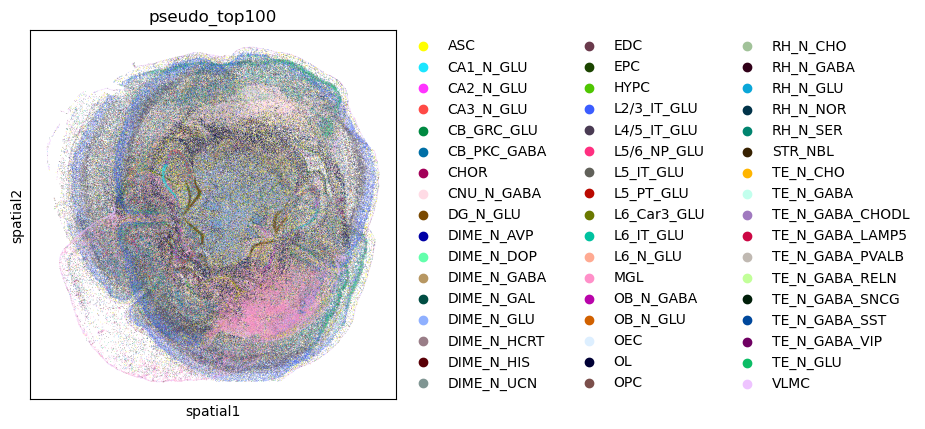

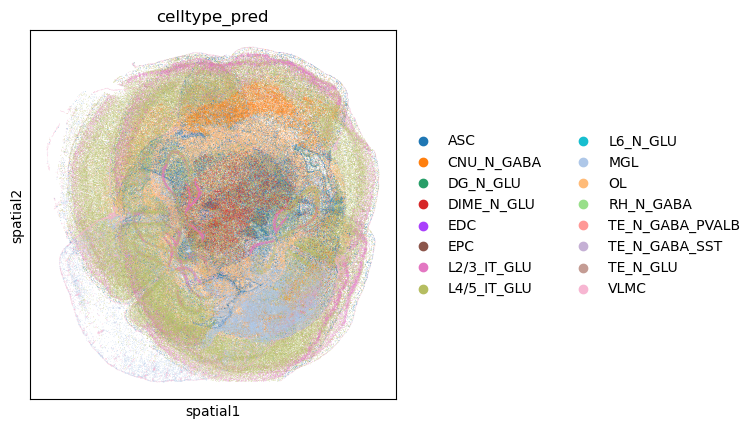

In [2]:
%reset -f
import gc
import torch
from spatialid import Transfer

tr = Transfer(
    single_data=None,   # 关键：第二步不要再读单细胞大文件
    spatial_data="inference_sp.h5ad",
    output_path="./spatialid_output",
    device=0
)

tr.sc2st("./spatialid_output/learn_sc_dnn.bgi")

tr.annotation(
    pca_dim=50,      # 先从 200 降到 50
    n_neigh=10,      # 先从 30 降到 10
    epochs=100,
    w_gae=0.1        # 降低图重构损失权重
)

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

# 可视化

In [ ]:
%reset -f
import squidpy as sq
import scanpy as sc

adata = sc.read("spatialid_output/annotation.h5ad")
sp_adata = sc.read("/media/williamhan/4E44841544840247/Python/bioinformatics_project/MCAO20250929/data/cellbin/MCAO20250929_reduce.h5ad")
adata, sp_adata

(AnnData object with n_obs × n_vars = 497563 × 19081
     obs: 'pseudo_class', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'celltype_pred'
     var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
     obsm: 'pseudo_label', 'spatial',
 AnnData object with n_obs × n_vars = 497563 × 19781
     obs: 'library', 'group', 'sample', 'accession', 'condition', 'time', 'batch', 'dnbCount', 'x', 'y', 'area', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_h

In [5]:
import pandas as pd

# 要同步的列
cols = ["pseudo_class", "celltype_pred"]

# 检查列是否存在
missing_cols = [c for c in cols if c not in adata.obs.columns]
if missing_cols:
    raise KeyError(f"adata.obs 中缺少这些列: {missing_cols}")

# 检查 obs index 是否唯一
if not adata.obs_names.is_unique:
    raise ValueError("adata.obs_names 不唯一，不能安全按 index 同步")

if not sp_adata.obs_names.is_unique:
    raise ValueError("sp_adata.obs_names 不唯一，不能安全按 index 同步")

# 查看匹配情况
common_idx = sp_adata.obs_names.intersection(adata.obs_names)
print(f"sp_adata cells: {sp_adata.n_obs}")
print(f"adata cells: {adata.n_obs}")
print(f"matched cells: {len(common_idx)}")
print(f"unmatched in sp_adata: {sp_adata.n_obs - len(common_idx)}")

# 按 sp_adata.obs_names 顺序重排 adata.obs 中对应列
mapped = adata.obs[cols].reindex(sp_adata.obs_names)

# 同步到 sp_adata.obs
for c in cols:
    sp_adata.obs[c] = mapped[c]

# 可选：检查同步后的缺失
print(sp_adata.obs[cols].isna().sum())

del adata
# # 保存
# sp_adata.write("MCAO20250929_reduce_with_spatialid_annotation.h5ad")

sp_adata cells: 497563
adata cells: 497563
matched cells: 497563
unmatched in sp_adata: 0
pseudo_class     0
celltype_pred    0
dtype: int64


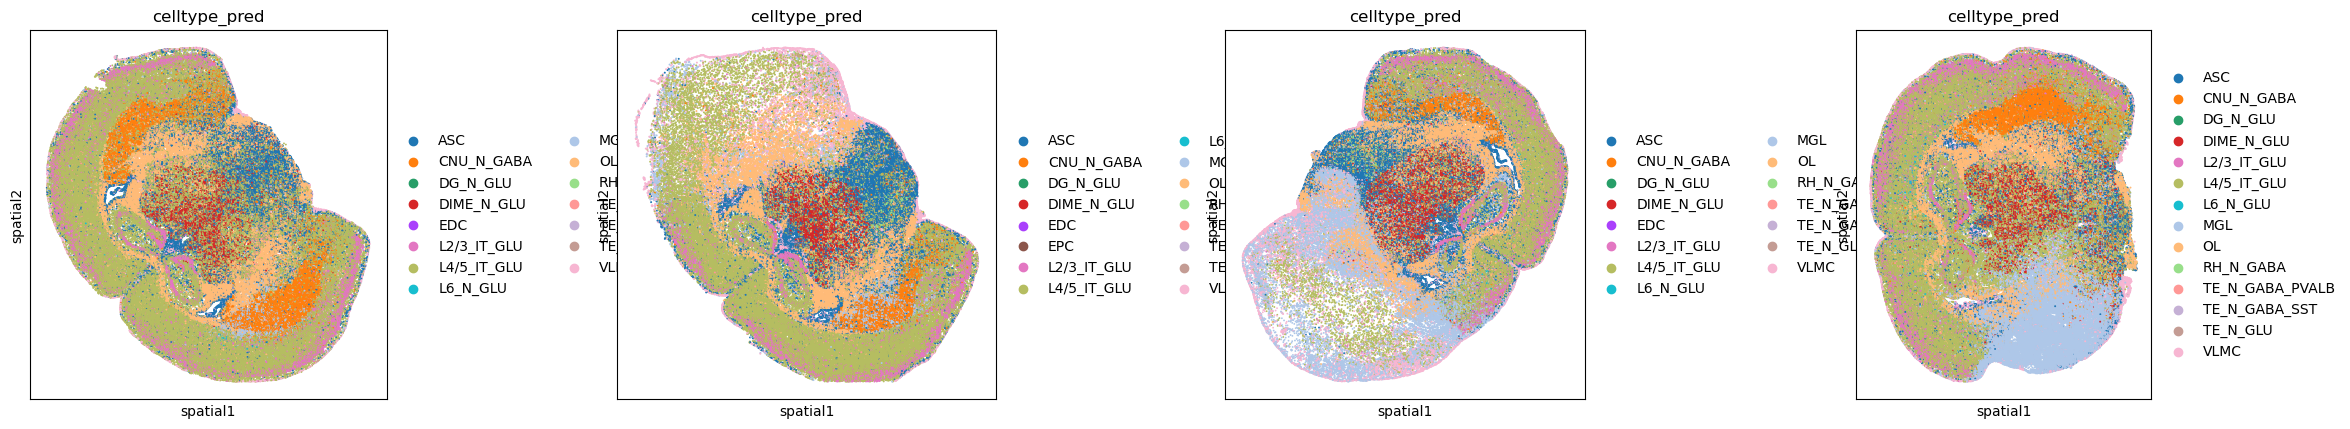

In [25]:
sq.pl.spatial_scatter(sp_adata, color="celltype_pred", library_key="library", library_id=["sham", "MCAO_1d", "MCAO_3d", "MCAO_14d",], img=False, size=50)

In [38]:
import squidpy as sq
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42
# ===== 基本参数 =====
color_key = "celltype_pred"
select_cluster = ["EPC"]
na_color = "#DEDEDE"
panels = ["sham", "MCAO_1d", "MCAO_3d", "MCAO_14d",]   # 每个子图显示的 library
library_key = "library"                               # 你的库字段
spatial_key = "spatial"                               # 你的空间坐标字段

# ===== 1) 取类别与颜色（不画图）=====
adata_plt = sp_adata.copy()
# 确保类别是分类类型，并拿到类别顺序
cats = adata_plt.obs[color_key].astype("category").cat.categories
# 建立 label→color 对应
color_map = pd.Series(adata_plt.uns[f"{color_key}_colors"], index=cats)
# # 除了 select_cluster 设置其他全灰
adata_plt.uns[f"{color_key}_colors"] = [na_color if idx not in select_cluster else row for idx, row in color_map.items()]

# ===== 2) 画多子图，但**不让每个子图自己画 legend** =====
fig, axes = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True)
axes_flat = axes.flatten()

for idx, lib in enumerate(panels):
    ax = axes_flat[idx]
    sq.pl.spatial_scatter(
        adata_plt,
        color=color_key,
        library_key=library_key,
        library_id=[lib],          # 指定只画这个库
        title=[lib],
        spatial_key=spatial_key,
        size=20,
        img=False,
        na_color=na_color,
        frameon=False,
        legend_loc=None,           # 关键：禁用每个子图自己的 legend
        legend_fontsize = 8,
        legend_fontweight = 'normal', # 默认是bold
        ax=ax,
        return_ax=True,
        # save=None  # 不保存，交互式看
    )
    ax.set_aspect("equal")

# 隐藏多余子图（如果 panels 少于子图数量）
for j in range(len(panels), len(axes_flat)):
    axes_flat[j].axis("off")

# ===== 3) 在 figure 级别统一 legend（使用 adata.uns 的颜色）=====
# 确保 legend 顺序与类别顺序一致；若类别是数字字符串，可按数字排序
def _try_int(x):
    try: return int(x)
    except: return x

cats_sorted = sorted(cats, key=_try_int)  # “0,1,2,10” 这种会按数值排
handles = [mpatches.Patch(color=pd.Series(adata_plt.uns[f"{color_key}_colors"], index=cats)[c], 
                          label=str(c)) for c in cats_sorted]

fig.legend(handles=handles, loc="center left", bbox_to_anchor=(1.05, 0.5),
           ncol=1, frameon=False, title="cluster")
# # 给右侧 legend 留出足够空间
# fig.subplots_adjust(
#     left=0.02,
#     right=0.72,   # 主图只占到 72%，右侧 28% 留给 legend
#     top=0.96,
#     bottom=0.03,
#     wspace=0.08,
#     hspace=0.15
# )

# 将当前坐标轴里的散点图对象栅格化
for artist in ax.collections:
    artist.set_rasterized(True)
plt.savefig(f"spatialid_output/{color_key}_predict.pdf", dpi=1200, 
            bbox_inches="tight"  # 关键：这会自动把画布外的 Legend 包含进来
            )

del adata_plt

KeyError: 'celltype_pred'